# Fixed Slope SSM Sensitivity

This notebook is a supplementary model-specification check for the connected-series main SSM.

Motivation: in the existing local-linear-trend SSM, the estimated slope disturbance can be very close to zero. This raises a reviewer-relevant question: do we need to estimate slope noise, or is a fixed / deterministic growth-rate specification sufficient?

This is not a replacement of the main specification. It is a sensitivity check comparing:

1. `baseline_m4`: current main-analysis SSM, local linear trend with estimated slope disturbance.
2. `fixed_slope_m4`: same exogenous variables, but the slope disturbance is fixed at zero by construction.

Implementation definition of fixed slope:

- The level and slope states are both retained.
- The transition remains `level_t = level_{t-1} + slope_{t-1}`, `slope_t = slope_{t-1}`.
- The slope state has no disturbance term in the selection matrix.
- Therefore the slope / growth-rate can be estimated as a latent deterministic state, but it cannot receive period-by-period stochastic shocks.

This is close to a local linear trend with deterministic slope, not a fully different deterministic time-trend regression.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_connected_parcel_data
from src.features import add_period_dummies
from src.forecasting.forecast_specs import get_forecast_spec
from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog

DATA_PATH = ROOT / "data" / "processed" / "parcel_volume_connected.csv"
SENSITIVITY_DIR = ROOT / "output" / "sensitivity"
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_BASE_PARAMS = ["obs_noise", "level_noise", "slope_noise", "seasonal_noise"]
FIXED_SLOPE_BASE_PARAMS = ["obs_noise", "level_noise", "seasonal_noise"]
EXOG_NAMES = ["hike_dummy", "covid_main", "covid_wave1", "covid_2021", "post_stat_change"]
COEFF_START_HINTS = {
    "covid_main": -2.0,
    "covid_wave1": -2.0,
    "covid_2021": -3.0,
}


## 1. Data And baseline_m4 Dummies

The connected parcel-volume series is loaded from `data/processed/parcel_volume_connected.csv`. The dependent variable is log parcel volume `y`. The event dummy set is the same as `baseline_m4`:

- `hike_dummy`
- `covid_main`
- `covid_wave1`
- `covid_2021`
- `post_stat_change`


In [2]:
df = load_connected_parcel_data(DATA_PATH)
baseline_spec = get_forecast_spec("baseline_m4")
df = add_period_dummies(df, baseline_spec["exog_periods"])

active_months = []
for name in EXOG_NAMES:
    active = df.index[df[name] == 1]
    active_months.append(
        {
            "dummy": name,
            "active_months": int(df[name].sum()),
            "first_active": active.min().strftime("%Y-%m-%d") if len(active) else None,
            "last_active": active.max().strftime("%Y-%m-%d") if len(active) else None,
        }
    )
active_months_df = pd.DataFrame(active_months)
active_months_df


,dummy,active_months,first_active,last_active
0,hike_dummy,27,2017-10-01,2019-12-01
1,covid_main,39,2020-03-01,2023-05-01
2,covid_wave1,2,2020-04-01,2020-05-01
3,covid_2021,9,2021-01-01,2021-09-01
4,post_stat_change,43,2022-08-01,2026-02-01


## 2. Fixed Slope Model Definition

The current SSM class estimates observation noise, level noise, slope noise, seasonal noise, and fixed exogenous coefficients.

The fixed-slope class below removes the slope disturbance from the state disturbance vector. In practice, the slope state remains in the transition equation, but the model no longer estimates `slope_noise`. This directly tests whether allowing stochastic slope shocks is necessary for this data.


In [3]:
class LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    # Local linear trend + seasonal + exog, with slope disturbance fixed at zero.

    def __init__(self, endog, exog_list, param_names, seasonal_period=12, **kwargs):
        self.k_seasonal = seasonal_period
        k_states = 2 + (self.k_seasonal - 1)
        k_posdef = 2  # level disturbance and seasonal disturbance only
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)

        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization="diffuse", **kwargs)

        self.ssm["design"] = np.zeros((1, k_states))
        self.ssm["design", 0, 0] = 1
        self.ssm["design", 0, 2] = 1

        transition = np.zeros((k_states, k_states))
        transition[0, 0] = 1
        transition[0, 1] = 1
        transition[1, 1] = 1
        transition[2, 2:] = -1
        for i in range(3, k_states):
            transition[i, i - 1] = 1
        self.ssm["transition"] = transition

        selection = np.zeros((k_states, k_posdef))
        selection[0, 0] = 1  # level noise
        selection[2, 1] = 1  # seasonal noise
        self.ssm["selection"] = selection

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm["obs_intercept"] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        constrained = unconstrained.copy()
        constrained[:3] = constrained[:3] ** 2
        return constrained

    def untransform_params(self, constrained):
        unconstrained = constrained.copy()
        unconstrained[:3] = np.sqrt(unconstrained[:3])
        return unconstrained

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]
        self["state_cov", 0, 0] = params[1]
        self["state_cov", 1, 1] = params[2]

        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[3 + i] * self.exogs[i]
        self["obs_intercept", 0, :] = total_exog_effect


## 3. Estimate baseline_m4 And fixed_slope_m4

Both specifications use the same data and the same fixed exogenous variables. Only the treatment of slope disturbance changes.


In [4]:
def make_param_names(base_params: list[str], exog_names: list[str]) -> list[str]:
    return base_params + [f"{name}_effect" for name in exog_names]


def build_start_params(base_params: list[str], exog_names: list[str]) -> list[float]:
    if base_params == BASELINE_BASE_PARAMS:
        init_variances = [0.01, 0.01, 0.001, 0.001]
    else:
        init_variances = [0.01, 0.01, 0.001]
    init_coeffs = [COEFF_START_HINTS.get(name, 0.0) for name in exog_names]
    return init_variances + init_coeffs


def compute_components(result, param_names: list[str]) -> dict:
    param_map = dict(zip(param_names, np.asarray(result.params, dtype=float)))
    trend = np.asarray(result.smoother_results.smoothed_state[0], dtype=float)
    seasonal = np.asarray(result.smoother_results.smoothed_state[2], dtype=float)
    effects = {}
    total_exog_effect = np.zeros(len(df), dtype=float)
    for exog_name in EXOG_NAMES:
        effect = param_map[f"{exog_name}_effect"] * df[exog_name].to_numpy(dtype=float)
        effects[exog_name] = effect
        total_exog_effect += effect
    fitted = trend + seasonal + total_exog_effect
    residual = df["y"].to_numpy(dtype=float) - fitted
    return {
        "trend": trend,
        "seasonal": seasonal,
        "effects": effects,
        "total_exog_effect": total_exog_effect,
        "fitted": fitted,
        "residual": residual,
    }


def fit_spec(model_id: str, model_class, base_params: list[str]) -> dict:
    param_names = make_param_names(base_params, EXOG_NAMES)
    exog_data = [df[name] for name in EXOG_NAMES]
    model = model_class(
        endog=df["y"],
        exog_list=exog_data,
        param_names=param_names,
        seasonal_period=12,
    )

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = model.fit(
            start_params=build_start_params(base_params, EXOG_NAMES),
            maxiter=1000,
            disp=False,
        )

    convergence_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]
    mle_retvals = getattr(result, "mle_retvals", {}) or {}
    params = np.asarray(result.params, dtype=float)
    bse = np.asarray(result.bse, dtype=float)
    zvalues = np.asarray(result.zvalues, dtype=float)
    pvalues = np.asarray(result.pvalues, dtype=float)

    components = compute_components(result, param_names)
    lb12 = acorr_ljungbox(components["residual"], lags=[12], return_df=True)
    lb24 = acorr_ljungbox(components["residual"], lags=[24], return_df=True)

    coefficient_rows = []
    for term, estimate, std_error, z_value, p_value in zip(param_names, params, bse, zvalues, pvalues):
        coefficient_rows.append(
            {
                "model_id": model_id,
                "term": term,
                "estimate": float(estimate),
                "std_error": float(std_error),
                "z_value": float(z_value),
                "p_value": float(p_value),
                "effect_percent": float(100 * (np.exp(estimate) - 1.0)) if term.endswith("_effect") else np.nan,
            }
        )

    summary = {
        "model_id": model_id,
        "status": "success",
        "error": "",
        "converged": bool(mle_retvals.get("converged", False)),
        "warnflag": mle_retvals.get("warnflag", np.nan),
        "convergence_warning": bool(convergence_warnings),
        "nobs": int(result.nobs),
        "log_likelihood": float(result.llf),
        "aic": float(result.aic),
        "bic": float(result.bic),
        "ljung_box_p_value_lag12": float(lb12["lb_pvalue"].iloc[0]),
        "ljung_box_p_value_lag24": float(lb24["lb_pvalue"].iloc[0]),
        "warning_messages": " | ".join(str(w.message) for w in convergence_warnings),
    }

    diagnostics = {
        **summary,
        "residual_mean": float(np.mean(components["residual"])),
        "residual_std": float(np.std(components["residual"], ddof=1)),
        "residual_rmse": float(np.sqrt(np.mean(components["residual"] ** 2))),
        "estimated_slope_noise": float(params[param_names.index("slope_noise")]) if "slope_noise" in param_names else 0.0,
        "slope_noise_definition": "estimated" if "slope_noise" in param_names else "fixed_at_zero_by_selection_matrix",
    }

    return {
        "model_id": model_id,
        "result": result,
        "param_names": param_names,
        "summary": summary,
        "diagnostics": diagnostics,
        "coefficients": coefficient_rows,
        "components": components,
    }


model_specs = [
    {
        "model_id": "baseline_m4",
        "model_class": LocalLinearTrendSeasonalWithMultiFixedExog,
        "base_params": BASELINE_BASE_PARAMS,
        "definition": "local linear trend with estimated slope disturbance",
    },
    {
        "model_id": "fixed_slope_m4",
        "model_class": LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog,
        "base_params": FIXED_SLOPE_BASE_PARAMS,
        "definition": "local linear trend with slope disturbance fixed at zero",
    },
]

outputs = {}
summary_rows = []
diagnostic_rows = []
coefficient_rows = []

for spec in model_specs:
    model_id = spec["model_id"]
    print(f"Estimating {model_id}: {spec['definition']}")
    try:
        output = fit_spec(model_id, spec["model_class"], spec["base_params"])
        outputs[model_id] = output
        summary_rows.append(output["summary"])
        diagnostic_rows.append(output["diagnostics"])
        coefficient_rows.extend(output["coefficients"])
    except Exception as exc:
        summary_rows.append(
            {
                "model_id": model_id,
                "status": "failed",
                "error": f"{type(exc).__name__}: {exc}",
                "converged": False,
                "warnflag": np.nan,
                "convergence_warning": False,
                "nobs": np.nan,
                "log_likelihood": np.nan,
                "aic": np.nan,
                "bic": np.nan,
                "ljung_box_p_value_lag12": np.nan,
                "ljung_box_p_value_lag24": np.nan,
                "warning_messages": "",
            }
        )

comparison_df = pd.DataFrame(summary_rows)
diagnostics_df = pd.DataFrame(diagnostic_rows)
coefficients_df = pd.DataFrame(coefficient_rows)
comparison_df


Estimating baseline_m4: local linear trend with estimated slope disturbance


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating fixed_slope_m4: local linear trend with slope disturbance fixed at zero


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model_id,status,error,converged,warnflag,convergence_warning,nobs,log_likelihood,aic,bic,ljung_box_p_value_lag12,ljung_box_p_value_lag24,warning_messages
0,baseline_m4,success,,True,0,False,287,584.069437,-1124.138874,-1043.630265,2.192728e-07,0.000011,
1,fixed_slope_m4,success,,True,0,False,287,584.071011,-1126.142022,-1049.292896,2.193729e-07,0.000011,


## 4. Model Comparison

The main comparison uses log likelihood, AIC, BIC, convergence status, and Ljung-Box p-values. Because `fixed_slope_m4` has one fewer variance parameter, AIC/BIC directly reflect the smaller parameter count.


In [5]:
comparison_df[[
    "model_id",
    "status",
    "converged",
    "warnflag",
    "convergence_warning",
    "nobs",
    "log_likelihood",
    "aic",
    "bic",
    "ljung_box_p_value_lag12",
    "ljung_box_p_value_lag24",
]]


,model_id,status,converged,warnflag,convergence_warning,nobs,log_likelihood,aic,bic,ljung_box_p_value_lag12,ljung_box_p_value_lag24
0,baseline_m4,success,True,0,False,287,584.069437,-1124.138874,-1043.630265,2.192728e-07,0.000011
1,fixed_slope_m4,success,True,0,False,287,584.071011,-1126.142022,-1049.292896,2.193729e-07,0.000011


## 5. Coefficients

The key question is whether fixing slope disturbance changes the event coefficients materially. `effect_percent` is `100 * (exp(estimate)-1)` for exogenous effect coefficients.


In [6]:
coefficients_df


,model_id,term,estimate,std_error,z_value,p_value,effect_percent
0,baseline_m4,obs_noise,2.341110e-04,3.708879e-05,6.312176,2.751385e-10,NaN
1,baseline_m4,level_noise,7.401869e-05,1.788444e-05,4.138720,3.492485e-05,NaN
2,baseline_m4,slope_noise,2.255708e-11,1.768996e-08,0.001275,9.989826e-01,NaN
3,baseline_m4,seasonal_noise,5.364100e-05,1.407488e-05,3.811117,1.383400e-04,NaN
4,baseline_m4,hike_dummy_effect,-2.335149e-02,2.721449e-02,-0.858054,3.908629e-01,-2.308095
5,baseline_m4,covid_main_effect,3.046673e-02,1.864794e-02,1.633786,1.023038e-01,3.093559
6,baseline_m4,covid_wave1_effect,5.119621e-02,1.787219e-02,2.864574,4.175704e-03,5.252939
7,baseline_m4,covid_2021_effect,1.617967e-02,1.262663e-02,1.281392,2.000560e-01,1.631127
8,baseline_m4,post_stat_change_effect,-4.529941e-02,2.464215e-02,-1.838290,6.601972e-02,-4.428871
9,fixed_slope_m4,obs_noise,2.340144e-04,3.691995e-05,6.338427,2.321223e-10,NaN


In [7]:
key_terms = [f"{name}_effect" for name in EXOG_NAMES]
coef_wide = coefficients_df[coefficients_df["term"].isin(key_terms)].pivot(
    index="term",
    columns="model_id",
    values=["estimate", "p_value", "effect_percent"],
)
coef_wide


estimate                    p_value                 \
model_id                baseline_m4 fixed_slope_m4 baseline_m4 fixed_slope_m4   
term                                                                            
covid_2021_effect          0.016180       0.016144    0.200056       0.201059   
covid_main_effect          0.030467       0.030233    0.102304       0.106645   
covid_wave1_effect         0.051196       0.051609    0.004176       0.003820   
hike_dummy_effect         -0.023351      -0.023347    0.390863       0.390622   
post_stat_change_effect   -0.045299      -0.045224    0.066020       0.063001   

                        effect_percent                 
model_id                   baseline_m4 fixed_slope_m4  
term                                                   
covid_2021_effect             1.631127       1.627492  
covid_main_effect             3.093559       3.069501  
covid_wave1_effect            5.252939       5.296422  
hike_dummy_effect            -2.308095      -2.307639  
post_stat_change_effect      -4.428871      -4.421632

## 6. Decomposition Figures

The figures mirror the existing SSM decomposition style: observed/fitted values, trend, seasonal component, external effects, and residuals. Both specifications are plotted on the same axes where possible.


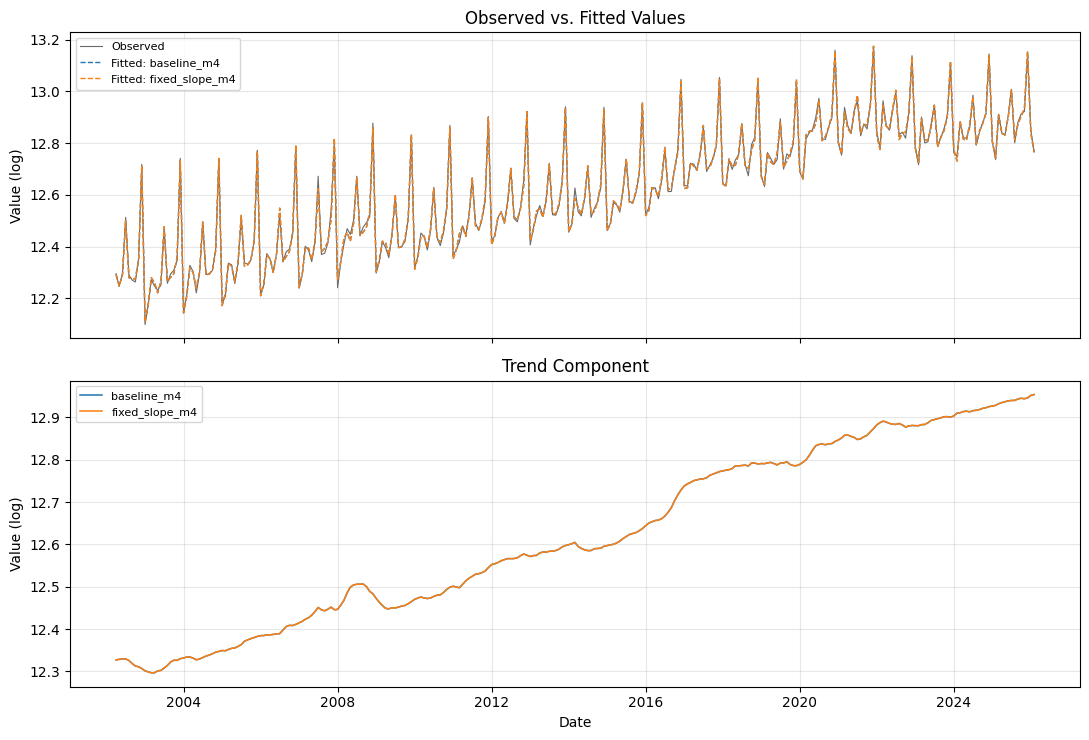

In [8]:
plot_model_ids = [model_id for model_id in ["baseline_m4", "fixed_slope_m4"] if model_id in outputs]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11, 7.5), sharex=True)
axes[0].plot(df.index, df["y"], color="dimgray", linewidth=0.8, label="Observed")
for model_id in plot_model_ids:
    axes[0].plot(
        df.index,
        outputs[model_id]["components"]["fitted"],
        linestyle="--",
        linewidth=1.0,
        label=f"Fitted: {model_id}",
    )
axes[0].set_title("Observed vs. Fitted Values")
axes[0].set_ylabel("Value (log)")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.3)

for model_id in plot_model_ids:
    axes[1].plot(df.index, outputs[model_id]["components"]["trend"], linewidth=1.1, label=model_id)
axes[1].set_title("Trend Component")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value (log)")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "fixed_slope_decomposition_main.png", dpi=300, bbox_inches="tight")
plt.show()


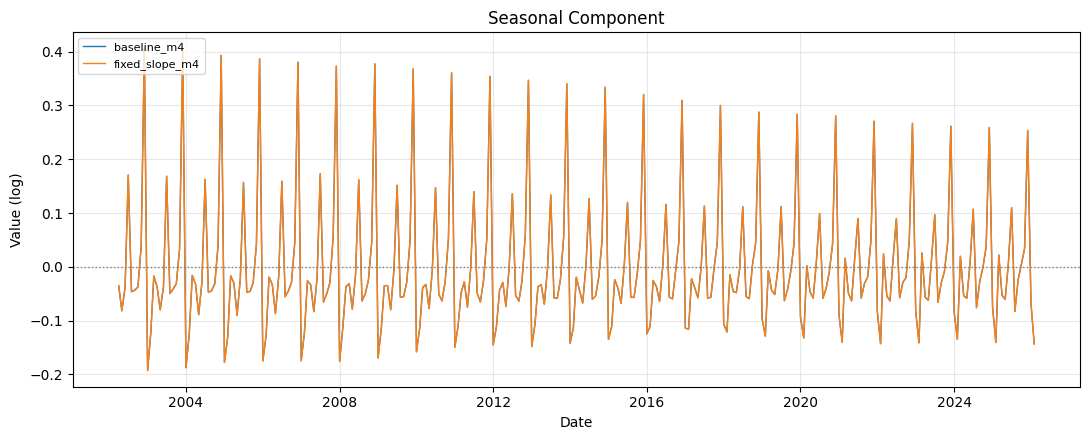

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for model_id in plot_model_ids:
    ax.plot(df.index, outputs[model_id]["components"]["seasonal"], linewidth=1.0, label=model_id)
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Seasonal Component")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "fixed_slope_decomposition_seasonal.png", dpi=300, bbox_inches="tight")
plt.show()


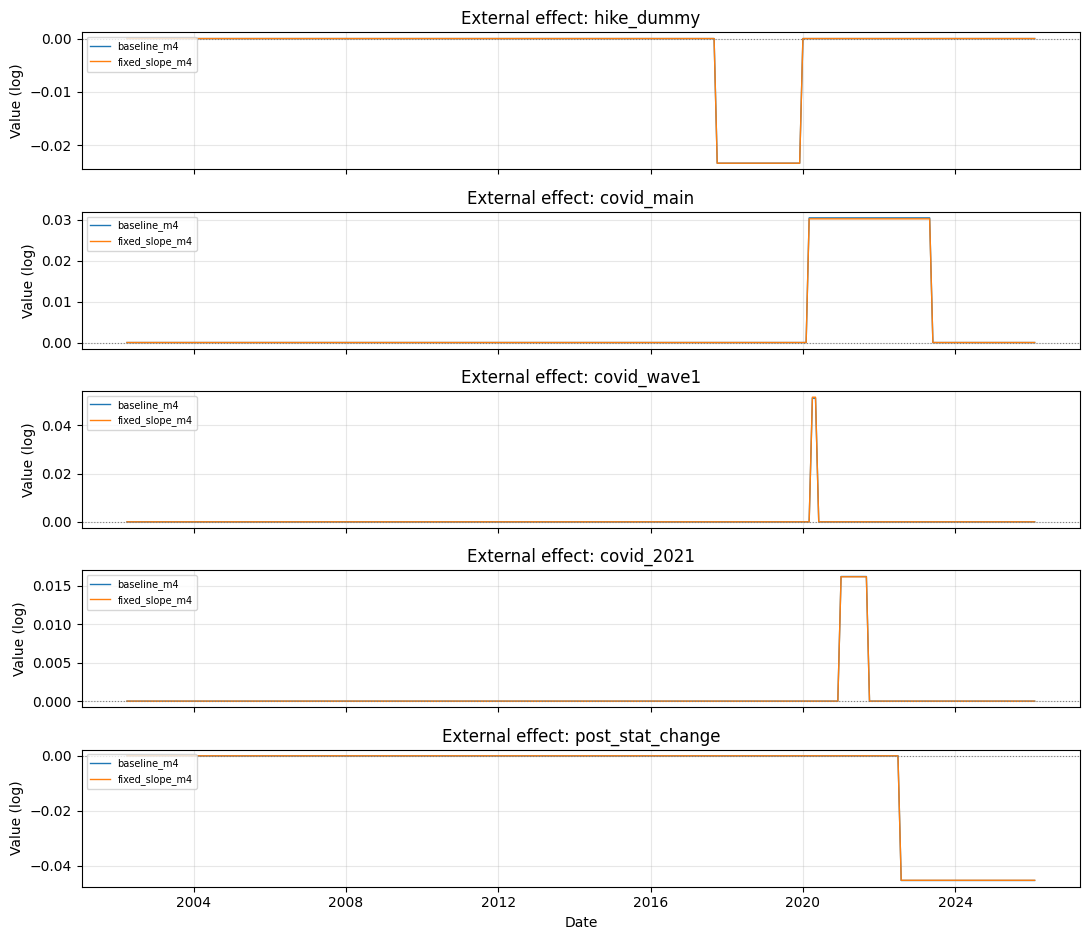

In [10]:
fig, axes = plt.subplots(nrows=len(EXOG_NAMES), ncols=1, figsize=(11, 9.5), sharex=True)
for ax, exog_name in zip(axes, EXOG_NAMES):
    for model_id in plot_model_ids:
        ax.plot(df.index, outputs[model_id]["components"]["effects"][exog_name], linewidth=1.0, label=model_id)
    ax.axhline(y=0, color="grey", linestyle=":", linewidth=0.8)
    ax.set_title(f"External effect: {exog_name}")
    ax.set_ylabel("Value (log)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "fixed_slope_decomposition_exog.png", dpi=300, bbox_inches="tight")
plt.show()


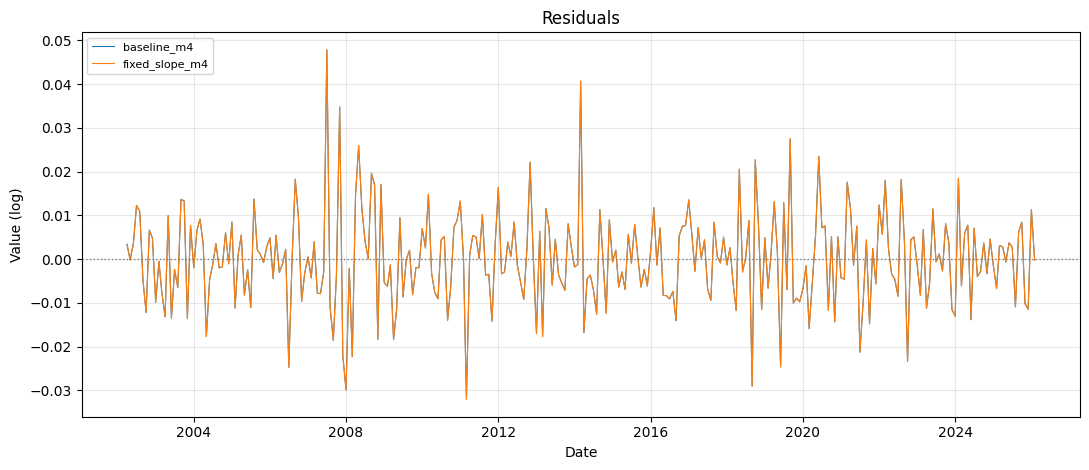

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for model_id in plot_model_ids:
    ax.plot(df.index, outputs[model_id]["components"]["residual"], linewidth=0.8, label=model_id)
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "fixed_slope_decomposition_residuals.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Save Tables


In [12]:
comparison_path = SENSITIVITY_DIR / "fixed_slope_model_comparison.csv"
coefficients_path = SENSITIVITY_DIR / "fixed_slope_coefficients.csv"
diagnostics_path = SENSITIVITY_DIR / "fixed_slope_diagnostics.csv"

comparison_df.to_csv(comparison_path, index=False)
coefficients_df.to_csv(coefficients_path, index=False)
diagnostics_df.to_csv(diagnostics_path, index=False)

for path in [comparison_path, coefficients_path, diagnostics_path]:
    print(f"saved {path}")
for name in [
    "fixed_slope_decomposition_main.png",
    "fixed_slope_decomposition_seasonal.png",
    "fixed_slope_decomposition_exog.png",
    "fixed_slope_decomposition_residuals.png",
]:
    print(f"saved {SENSITIVITY_DIR / name}")


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_model_comparison.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_coefficients.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_diagnostics.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_decomposition_main.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_decomposition_seasonal.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_decomposition_exog.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\fixed_slope_decomposition_residuals.png


## 8. Reading Notes

- This is a supplementary specification check, not a proposal to replace the main model.
- `fixed_slope_m4` fixes the slope disturbance to zero by removing the slope disturbance from the state selection matrix. It still has a latent slope state.
- If AIC/BIC improve and coefficients remain stable, this suggests that estimating stochastic slope noise may not be necessary for this connected series.
- If trend, seasonal, or exogenous effects change substantially, the fixed-slope restriction should be treated cautiously.
- Residual autocorrelation diagnostics should still be checked; fixing slope disturbance alone may not solve residual dependence.
